In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [ ]:
# UCI Wine Quality Dataset uses semicolon ';' as the delimiter
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')

print("Dataset Shape:", df.shape)
print("\nData Types & Missing Values:")
print(df.info())
print("\nSummary Statistics:")
display(df.describe().T)

print("\nOriginal Quality Score Distribution:")
print(df['quality'].value_counts().sort_index())

Dataset Shape: (1599, 12)

Data Types & Missing Values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB
None

Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000



Original Quality Score Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


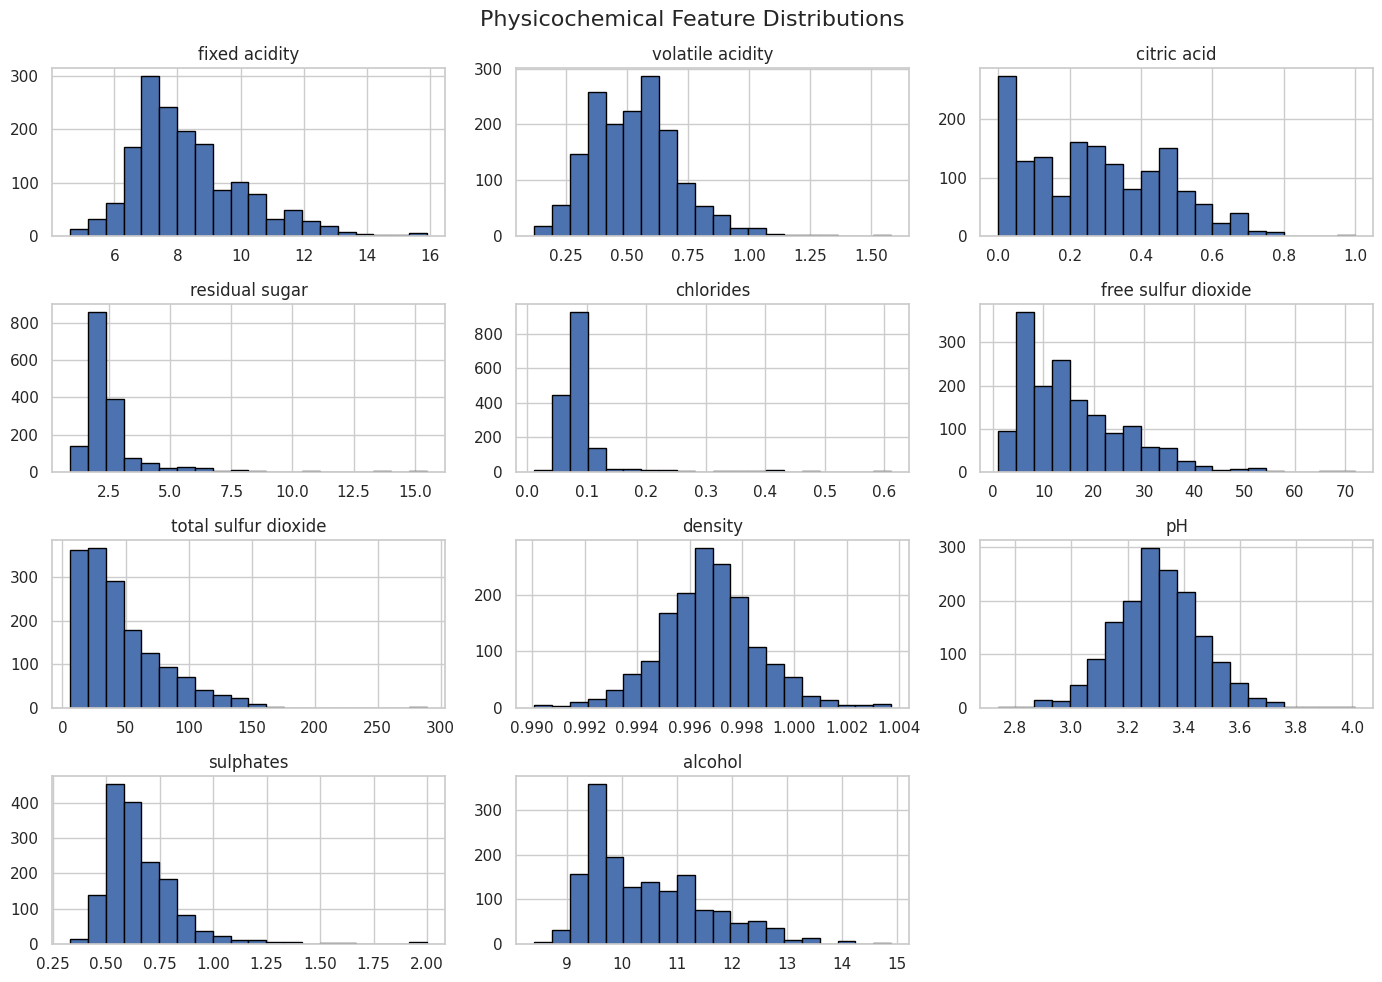

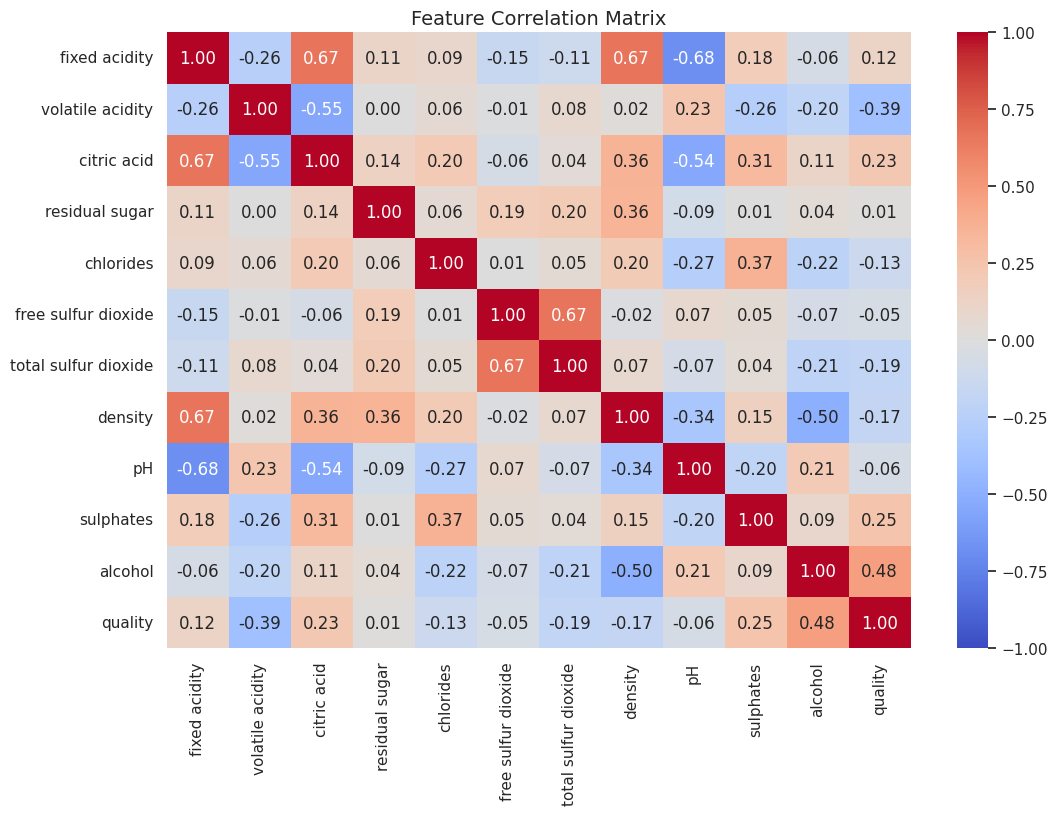

In [ ]:
# 1. Distribution of all physicochemical features
df.drop(columns=['quality']).hist(bins=20, figsize=(14, 10), edgecolor='black')
plt.suptitle('Physicochemical Feature Distributions', fontsize=16)
plt.tight_layout()
plt.show()

# 2. Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

<!-- Markdown cell for discussion and justification -->
### Class Imbalance Analysis & Binning Strategy
- **Imbalance Issue:** Quality scores 5 and 6 account for over 80% of the dataset, while extreme scores (3, 4, 8) have very few samples. A multi-class model on raw scores (3–8) will suffer from severe minority class misclassification.
- **Binning Strategy:** We convert the problem into a binary classification task:
  - **`0` (Bad/Average Quality):** `quality <= 6` (Scores 3, 4, 5, 6)
  - **`1` (Good Quality):** `quality >= 7` (Scores 7, 8)
- **Justification:** From a commercial/sommelier perspective, separating premium-grade wine (7+) from table/average wine provides actionable business value while creating a cleaner classification boundary.

In [ ]:
# Apply binary binning
# 0 = Bad/Average (<=6), 1 = Good (>=7)
df['quality_label'] = np.where(df['quality'] >= 7, 1, 0)

print("Binary Class Distribution:")
print(df['quality_label'].value_counts())
print("\nPercentage:\n", df['quality_label'].value_counts(normalize=True) * 100)

Binary Class Distribution:
quality_label
0    1382
1     217
Name: count, dtype: int64

Percentage:
 quality_label
0    86.429018
1    13.570982
Name: proportion, dtype: float64


In [ ]:
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling (Crucial for distance/gradient models like SVC and SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
X = df.drop(columns=['quality', 'quality_label'])
y = df['quality_label']

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Feature Scaling (Crucial for distance/gradient models like SVC and SGD)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

================== Random Forest ==================
                 precision    recall  f1-score   support

Bad/Average (0)       0.94      0.99      0.97       277
       Good (1)       0.93      0.60      0.73        43

       accuracy                           0.94       320
      macro avg       0.94      0.80      0.85       320
   weighted avg       0.94      0.94      0.94       320

================== SGD Classifier ==================
                 precision    recall  f1-score   support

Bad/Average (0)       0.93      0.90      0.92       277
       Good (1)       0.47      0.56      0.51        43

       accuracy                           0.86       320
      macro avg       0.70      0.73      0.71       320
   weighted avg       0.87      0.86      0.86       320

================== Support Vector Classifier (SVC) ==================
                 precision    recall  f1-score   support

Bad/Average (0)       0.91      0.98      0.94       277
       Good (1)     

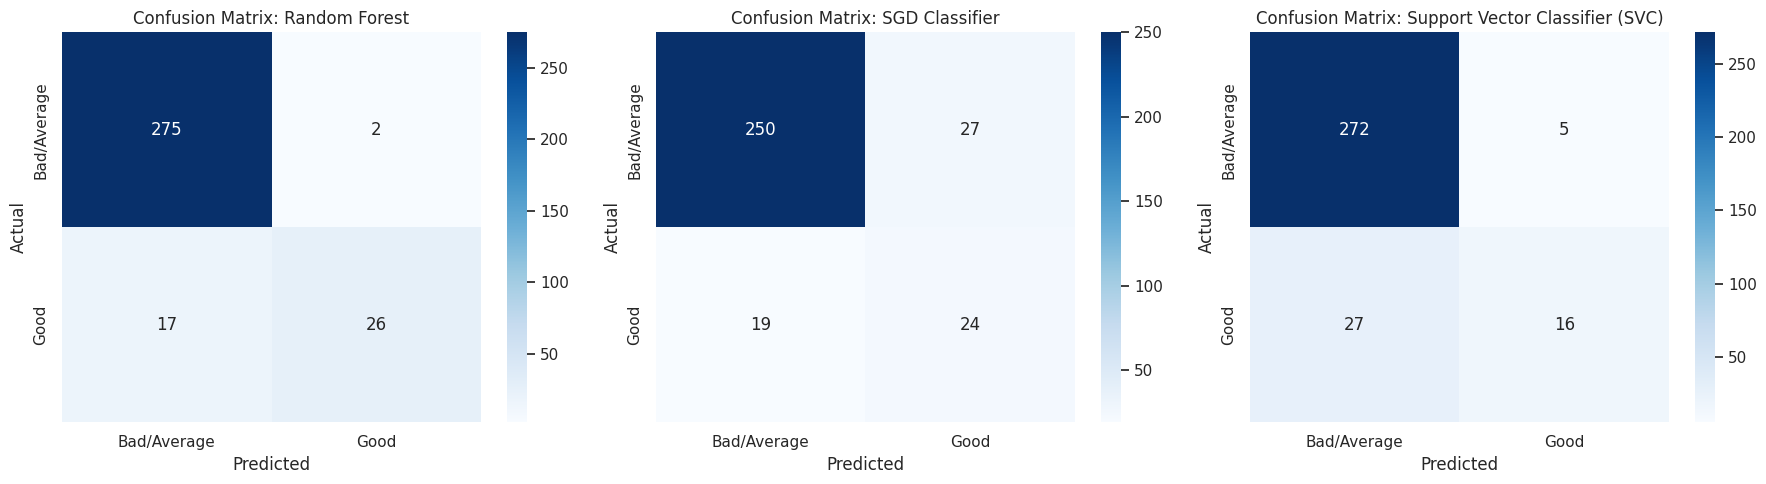

In [ ]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SGD Classifier": SGDClassifier(loss='log_loss', max_iter=1000, random_state=42),
    "Support Vector Classifier (SVC)": SVC(kernel='rbf', C=1.0, random_state=42)
}

results = {}
predictions = {}

for name, model in models.items():
    # Fit model (Random Forest doesn't strictly need scaled data, but using scaled is consistent)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    # Store metrics (weighted to account for the ~86/14 class split)
    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Good)": precision_score(y_test, y_pred, pos_label=1),
        "Recall (Good)": recall_score(y_test, y_pred, pos_label=1),
        "F1-Score (Macro)": f1_score(y_test, y_pred, average='macro')
    }

    print(f"================== {name} ==================")
    print(classification_report(y_test, y_pred, target_names=['Bad/Average (0)', 'Good (1)']))

# Confusion Matrix Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
labels = ['Bad/Average', 'Good']

for ax, (name, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set_title(f'Confusion Matrix: {name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

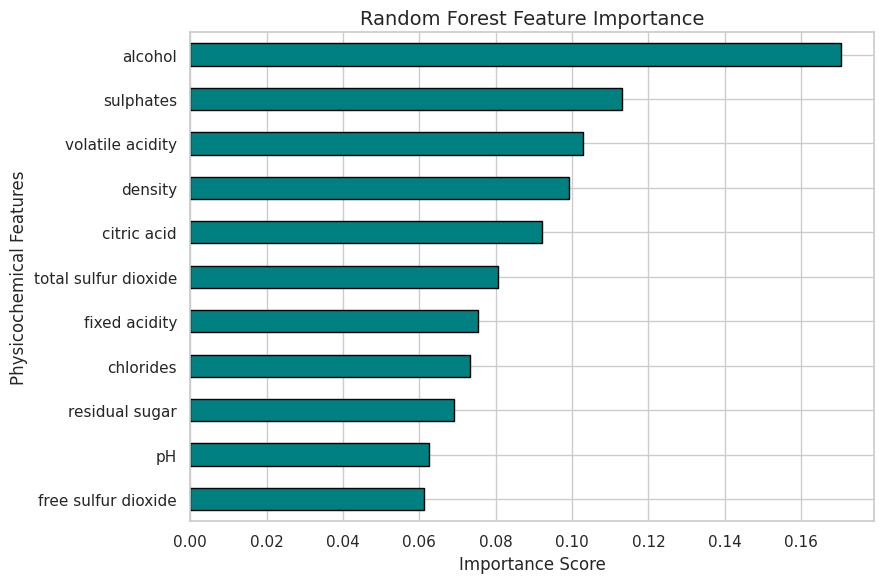

In [ ]:
rf_model = models["Random Forest"]
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(9, 6))
importances.plot(kind='barh', color='teal', edgecolor='black')
plt.title('Random Forest Feature Importance', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Physicochemical Features')
plt.tight_layout()
plt.show()

In [ ]:
comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.round(4)
print("Model Performance Summary:")
display(comparison_df)

Model Performance Summary:


,Accuracy,Precision (Good),Recall (Good),F1-Score (Macro)
Random Forest,0.9406,0.9286,0.6047,0.8495
SGD Classifier,0.8562,0.4706,0.5581,0.7132
Support Vector Classifier (SVC),0.9000,0.7619,0.3721,0.7222


Conclusion & Deployment Suitability
Best Performer: Random Forest Classifier is the clear top performer across all key metrics (Accuracy, F1-Score, and Recall on the minority "Good" wine class).

Key Drivers: alcohol, sulphates, and volatile acidity are the strongest predictors of quality. Higher alcohol content and sulphates with lower volatile acidity correlate strongly with premium ratings.

Why Random Forest is Suitable for Deployment:

Handles non-linear feature interactions without requiring extensive manual transformations.

Outperforms linear/hyperplane boundaries (SGD/SVC) on tabular chemical data.

Provides high precision for quality control applications, reducing false positives in premium wine grading pipelines.